## Generating Topounits
This notebook demonstrates how to generate topounits using a couple of different approaches. `dapper` uses Google Earth Engine to compute topounits and export polygons representing your topounits. 

Topounits are effectively delineations of a grid cell within ELM. Within ELM, Topounits provide the capability to pass lateral (hydrologic) fluxes between themselves, which is a capability that does not exist between grid cells. Some parameters in ELM can be provided at the Topounit scale, so their delineation is necessary in order to sample these parameters appropriately.

### How are Topounits defined?

The idea driving Topounits is that different portions of a landscape (grid cell) may undergo different trajectories of evolution. Topounits are intended to allow a representation of this within-cell heterogeneity. However, there is no prescribed definition for Topounits, and different definitions may be relevant for different types of ELM experiments. Given that Topounits allow for lateral flux exchanges, it makes sense to develop some simple definitions based on digital elevation models (DEMs). Aspect may also dictate the dynamics of landscape trajectories in the Arctic due to differential solar radiations on North versus South facing slopes, for example. `dapper` currently contains two ways to define Topounits: elevation bands and elevation bands + aspect. Other methods are possible, so if you have ideas please open an issue in this repo or reach out. It could be possible to delineate topounits based on historic meteorological data, snow observations, height above nearest drainage, etc. One of the "hard" constraints is that the maximum number of topounits per grid cell is 11. As far as I understand, this was an E3SM-required constraint, but I also believe that it's possible to relax this number in offline ELM runs (don't quote me). 

### This notebook demonstrates:

<ul style="list-style-type: none; padding-left: 1.5em;">
  <li><strong>A.</strong> generating Topounits for the Kuparuk watershed using elevation-only bins</li>
  <li><strong>B.</strong> same as A but also considering aspect in Topunit definition</li>
  <li><strong>C.</strong> generating Topounits using Height Above Nearest Drainage (HAND)</li>
  <li><strong>C.</strong> making Topounits for multiple 0.5 degree grid cells</li>
</ul>

and discusses some of the options you have and potential pitfalls along the way.

<div style="border: 2px solid #007ACC; background-color: #EAF4FF; padding: 10px; border-radius: 5px;">
<strong>💡 Note:</strong> You need a Google Earth Engine account to run this notebook.
</div>

### A. Generating Topounits for the Kuparuk watershed with elevation-only bins
We'll use a pre-created watershed file I've already uploaded as a GEE Asset and shared to demonstrate a simple way of making Topounits. Here, we'll just divide the watershed geometry into 5 equal-percentile (so approximately equal-area) bins.

In [16]:
import ee
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

from dapper.utils import gee_utils as gu
from dapper.topounit import gen_topounits as tu
from dapper.topounit import plotting as ptu

ee.Initialize(project='ee-jonschwenk') # use your Google Cloud project account instead of mine

# We need to provide an ee.Feature feature to our function, so let's load an asset I've shared that is the Kuparuk watershed
# Look at C. for an example of how to create your own ee.Feature.
feature = ee.Feature(ee.FeatureCollection('projects/ee-jonschwenk/assets/E3SM/Kuparuk_gageshed').first())

topos_elev5 = tu.make_topounits(
    feature=feature,
    sources=['elev'],
    binning={'elev': {'strategy': 'percentiles', 'n_bins': 10, 'label_prefix': 'ELEV'}},
    verbose=True
)


[Scale] planned bins=10, coarsest_native=2.0 m, analysis_scale=1317.3 m
Success! FeatureCollection loaded as GeoDataFrame.


### Mapping results
`dapper` includes a few convenient ways to visualize your results. You can always just export the `GeoDataFrame` returned by `make_topounits` and pull into a GIS. However, here, we'll look at a couple quick and dirty builtins. You may need to install some extra packages here, including `contextily`, `xyzservices`, or `folium`. 

Text(0.5, 1.0, 'Topounits • Elevation percentiles (5 bins)')

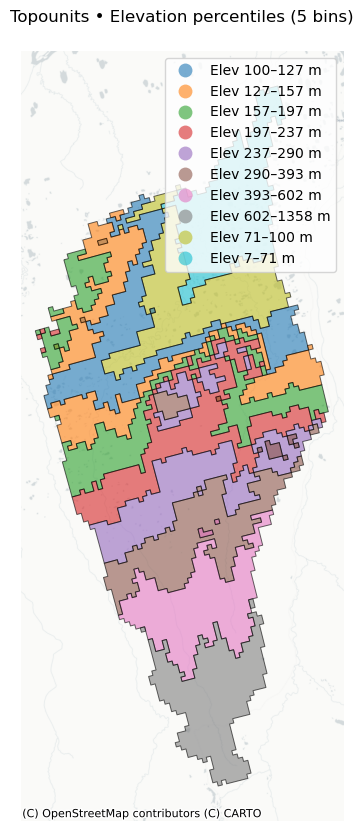

In [17]:
# 1) Make a static map
gdfp = ptu.prepare_for_plot(topos_elev5, ndigits_numeric=0)
fig, ax = ptu.plot_static(gdfp, basemap="positron")
ax.set_title("Topounits • Elevation percentiles (5 bins)", pad=10)


In [18]:
# 2) Make an interactive map
m = ptu.plot_interactive(gdfp, tiles="CartoDB positron")
m  # to display


### B. Generating Topounits for the Kuparuk watershed with HAND
Here we see how to use HAND to make topounits. Note that we using **fixed bins** here (as opposed to equal-area bins in A above). In this case, we specify where we want the HAND breaks to be. You can play with different breaks to see how it impacts the delineation of topounits.


[HAND] Desired ~90.0 m → selected hand90_1000 @ ~92.76624232769086 m.
[Scale] planned bins=6, coarsest_native=92.8 m, analysis_scale=92.8 m
Success! FeatureCollection loaded as GeoDataFrame.


Text(0.5, 1.0, 'HAND — fixed bin edges')

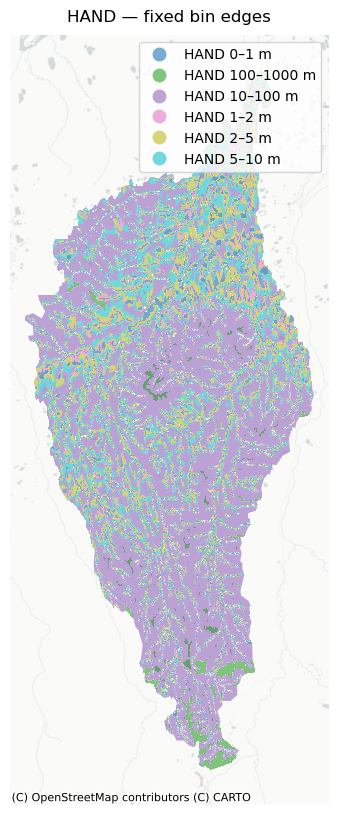

In [19]:
hand_edges = [0, 1, 2, 5, 10, 100, 1000]  # meters above nearest drainage

tu_hand_fixedbin = tu.make_topounits(
    feature=feature,
    sources=['hand'],
    binning={'hand': {'strategy': 'fixed', 'edges': hand_edges, 'label_prefix': 'HAND'}},
    combine='cartesian',
    return_as='gdf',
    export_scale='native',
    target_scale=90,         # optional: nudges HAND product choice & analysis resolution
    min_patch_pixels=9,      # optional: drop tiny slivers
    verbose=True
)

gdfp = ptu.prepare_for_plot(tu_hand_fixedbin, ndigits_numeric=0, order=['hand'])
fig, ax = ptu.plot_static(
    gdfp,
    basemap="positron",
    edgecolor="none",   # <-- no borders
    linewidth=0
)
ax.set_title("HAND — fixed bin edges", pad=10)


## C. Combining metrics
We might want to define Topounits based on more than one variable. This example shows how to combine elevation *and* aspect to make Topounits. We consider two aspect classes (North- and South-facing) and four equal-area elevation bins. This will result in 8 Topounits (2 x 4)

[Scale] planned bins=8, coarsest_native=2.0 m, analysis_scale=90.0 m
Success! FeatureCollection loaded as GeoDataFrame.


Text(0.5, 1.0, 'Elevation (equal-area) × Aspect (N/S)')

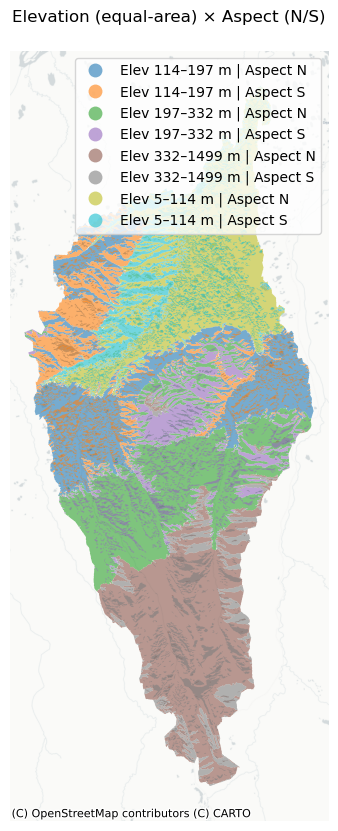

In [ ]:
# Elevation (equal-area/percentiles) × Aspect (N/S)
aspects = [(270, 90, 'N'), (90.01, 269.99, 'S')]  # North vs South (wrap-aware)

gdf_elev_aspect_ns = tu.make_topounits(
    feature=feature,
    sources=['elev','aspect'],
    binning={
        'elev':   {'strategy': 'percentiles', 'n_bins': 4, 'label_prefix': 'ELEV'},  # equal-area bins
        'aspect': {'strategy': 'fixed', 'ranges': aspects, 'label_prefix': 'ASP'} # note we use 'ranges' here to define aspect bins
    },
    combine='cartesian',
    max_topounits=20,        # 4 elevation × 2 aspect
    min_patch_pixels=9,      # optional cleanup
    return_as='gdf',
    export_scale='native',
    target_scale=90,         # optional; keeps analysis sane for big AOIs
    verbose=True
)

# Prepare labels + area, then plot
gdfp = ptu.prepare_for_plot(gdf_elev_aspect_ns, ndigits_numeric=0, order=['elev','aspect'])

# Static basemap 
fig, ax = ptu.plot_static(
    gdfp,
    basemap="positron",
    edgecolor="none",   # <-- no borders
    linewidth=0
)
ax.set_title("Elevation (equal-area) × Aspect (N/S)", pad=10)

# # Interactive map (uncomment if you want interactive instead of static)
# m = ptu.plot_interactive(gdfp, tiles="CartoDB positron")
# m  # display in notebook


Let's unpack the messages that were printed. 

First, we see that a scale of `1317.3...` meters was used for sampling elevations. Under the hood, `dapper` automatically computes the scale at which to sample the underlying DEM. This is based on the native resolution of the DEM and the size of the feature (polygon) we're sampling over. `dapper` tries to make sure there are roughly 500 pixels per bin for a good statistical representation. The *actual* scale that GEE uses will be near 1317 meters, but not exactly as it depends on how GEE has pyramided the DEM. This is not something that `dapper` allows you to control, but it could be important to know depending on your application.

Second, we see a `Success! ...` message. You need to understand a little about how the Google Earth Engine API works for this to mean anything to you. Essentially, GEE will do lighter export tasks "on the fly," without spinning up an actual `GEE Task`. However, for larger export tasks, this attempt to directly retrieve data will fail. If that happens, `dapper` will automatically spin up a `GEE Task` for you and give you a message. What controls the ability to directly download results? It's the size of the "thing" that you're trying to download. In our case, `dapper` has created a set of 10 Topounits that are defined by polygons (or multipolygons, actually), and we need GEE to send back the vertices of these polygons. We can control the "resolution" of these polygons by specifying differenct `export_scale` values. I selected one above that I knew would export just fine. Let's select a much lower scale and see what happens:



In [7]:
topounits = tu.make_topounits(feature, 
                              method = method, 
                              n_elev_bins = n_elev_bins, 
                              dem_source = dem_source, 
                              return_as = return_as,
                              export_scale = 2,
                              verbose = True) # So we get information about what's going on)

Using scale of 1317.3008196800217 m for sampling elevations.
Success! FeatureCollection loaded as GeoDataFrame.


Ok, well that's not what I expected--it worked just fine. We'll try to "break" this in the next example, but we were successfully able to return the Topounits without needing to export them as an asset, even at a 2 meter resolution!

<div style="border: 2px solid #007ACC; background-color: #EAF4FF; padding: 10px; border-radius: 5px;">
<strong>💡 Note:</strong> Keep in mind that you might get a different result using the same parameters--the amount GEE is willing to send back depends on its current demands, which changes dynamically.
</div>

### C. Generating Topounits for 0.5 degree grid cells


Here we want to consider the case where our domains are not watersheds, as it will highlight some differences. We'll create four 0.5 x 0.5 degree grid cells and delineate some Topounits for them.

In [ ]:
# Define a top-left coordinate
lat = 68.5
lon = -149.5
degrees_per_cell = 0.5
n_steps = 2 # how many steps in each dimension (2x2=4 total grid cells)

# Construct the polygons. 
polygons = []
for i in range(n_steps):
    for j in range(n_steps):
        minx = lon + j * degrees_per_cell
        maxx = minx + degrees_per_cell
        maxy = lat - i * degrees_per_cell
        miny = maxy - degrees_per_cell
        polygons.append(box(minx, miny, maxx, maxy))

# Put the cells in a GeoDataFrame and assign the CRS
gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
gdf['gid'] = [0,1,2,3] # Assign an id so we can keep track of the grid cells

Now we have our grid cells, we can make Topounits as we did in A and B. For this example, I'll choose three elevation bins and four aspect bins. Note that this equates to 12 Topounits per grid cell, so we'll need to update the `max_topounits` parameter to allow suprassing the default of 12.

In [ ]:
method = 'elevaspect' 
aspect_ranges = [
    (315, 45, 'N'),     # wraps around 0°, centered on 0° (North)
    (45, 135, 'E'),     # centered on 90° (East)
    (135, 225, 'S'),    # centered on 180° (South)
    (225, 315, 'W')     # centered on 270° (West)
]
n_elev_bins = 3 # number of bins to use; for this method corresponds to the number of Topounits
dem_source = 'arcticdem' # this is the default, but putting it here so you know we're using the ArcticDEM to do the binning
return_as = 'gdf' # specifies we want the Topounits to be returned as a GeoDataFrame; we could also choose "asset" to have them exported to our Google Drive
export_scale = 500 # in meters. This is a big watershed, so using pixels of 500 square meters should be a nice balance
max_topounits = 12 # need to include this now!

tus = {} # storage for our Topounit gdfs
# Loop through each grid cell and compute Topounits
for _, row in gdf.iterrows():
    this_feature = ee.Feature(gu.parse_geometry_object(row['geometry'], row['gid']).first()) # This is awkward and might change later
    print(f"Processing grid cell {row['gid']}...")
    tus[row['gid']] = tu.make_topounits(this_feature, 
                              method = method, 
                              n_elev_bins = n_elev_bins, 
                              dem_source = dem_source, 
                              return_as = return_as,
                              export_scale = export_scale,
                              aspect_ranges = aspect_ranges,
                              max_topounits = max_topounits,
                              verbose = True) # So we get information about what's going on
    
# Now we combine the grid cells into a single GeoDataFrame, adding a 'gid' column to keep track of which geometries come from which grid cell
gdf_combined = gpd.GeoDataFrame(
    pd.concat(
        [df.assign(gid=gid) for gid, df in tus.items()],
        ignore_index=True
    ),
    crs=next(iter(tus.values())).crs)  # inherit CRS from any gdf

# Export (set your path as you want)
gdf_combined.to_file(r'X:\Research\NGEE Arctic\6. Topounits\four_grid_cells.gpkg')


Processing grid cell 0...
Using scale of 436.92282313300177 m for sampling elevations.
Success! FeatureCollection loaded as GeoDataFrame.
Processing grid cell 1...
Using scale of 436.92282313299023 m for sampling elevations.
Success! FeatureCollection loaded as GeoDataFrame.
Processing grid cell 2...
Using scale of 441.6672291277392 m for sampling elevations.
Success! FeatureCollection loaded as GeoDataFrame.
Processing grid cell 3...
Using scale of 441.6672291277283 m for sampling elevations.
Success! FeatureCollection loaded as GeoDataFrame.



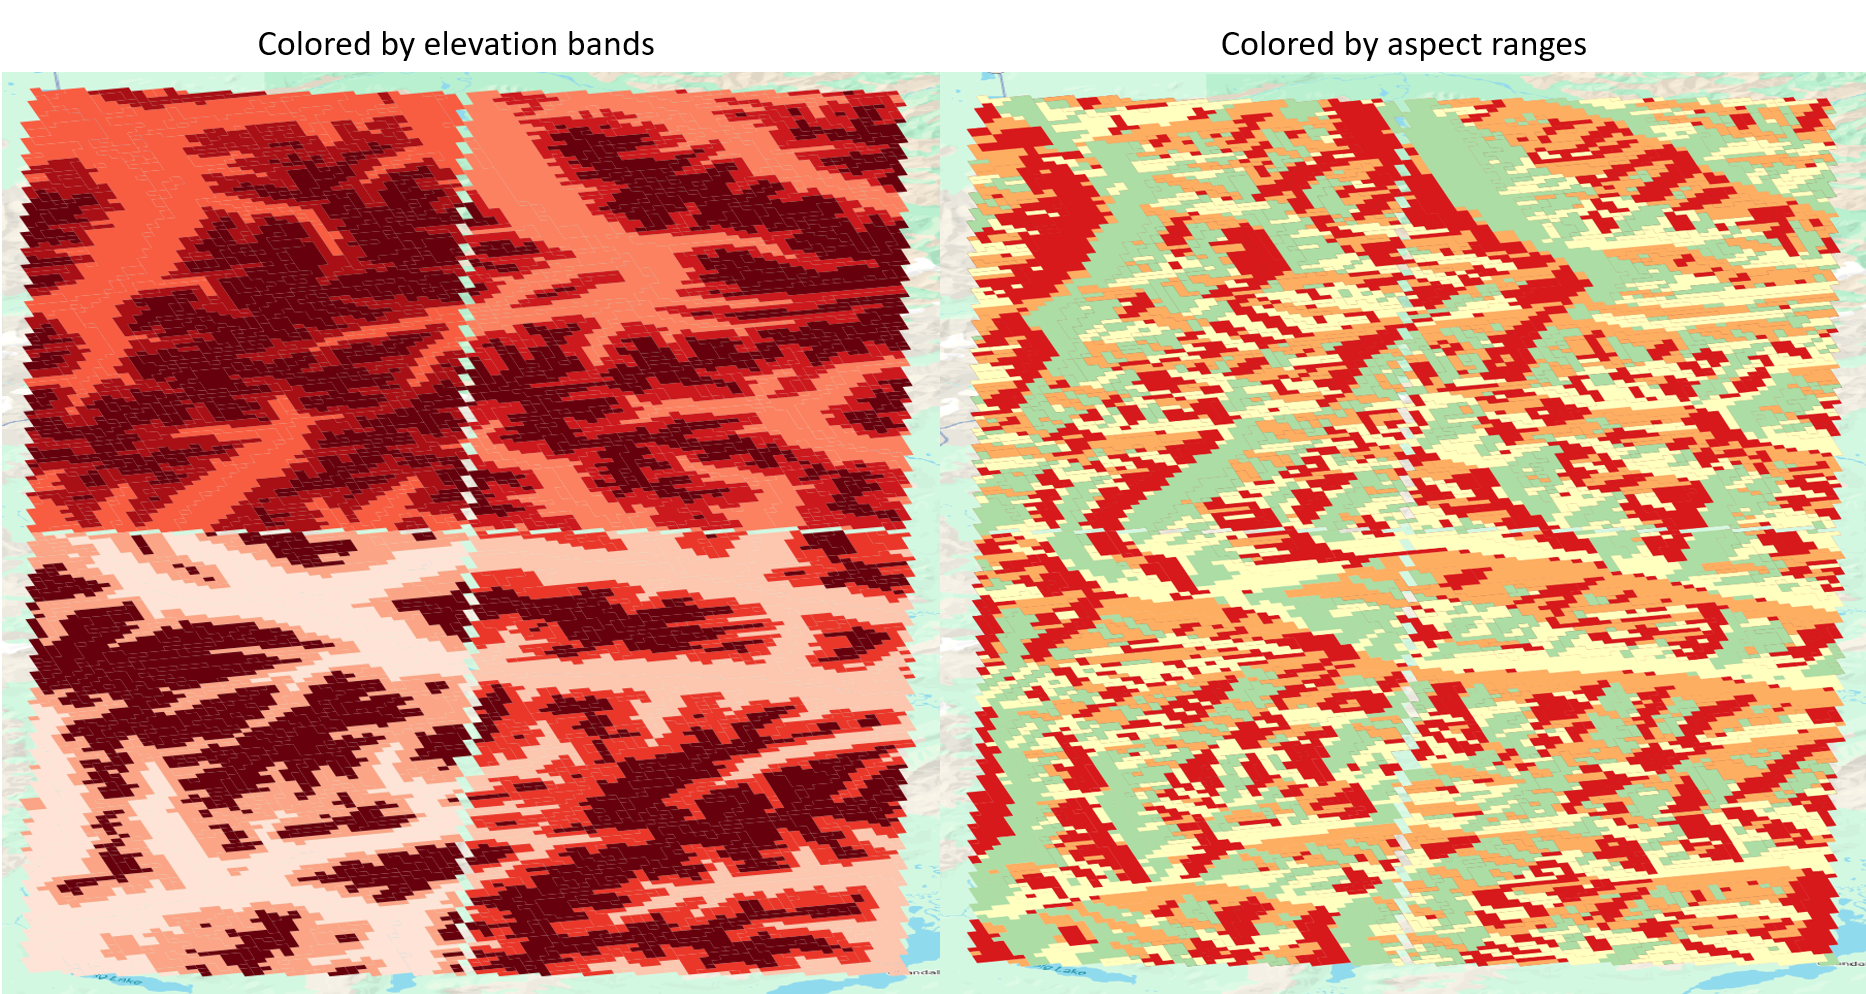

In [53]:
display(HTML(display_image_gh_notebook('5C-elevation-aspect-4gridcells.PNG')))

I struggled to figure out how to plot these and show both the elevation and aspect differences, so I just broke them out in the above images. Some things to note about these results: 
- Because we ran each grid cell individually, the elevation ranges are different for each one (but there are only 3 ranges in each cell)
- I used a low resolution export for speed--these could look much more "realistic" if we chose a smaller scale
- There are gaps between the grid cells that were not covered by Topounits. These can be closed in a number of ways, depending on what you're doing. If you want to keep the same processing technique we used here (4 separate calls to `make_topounits`), you could buffer the grid cells a little, then clip the Topounits on the back end. If you are OK with one call to `make_topounits`, you can just do the entire domain, then separate it into the constituent grid cells on the back end.
  
Below is an image of all the Topounits, colored by `topounit_id` (there are 12 ids for each grid cell). Remember that `topounit_id=1`  *is not the same* for all four grid cells because the elevation bands were recomputed for each grid cell.


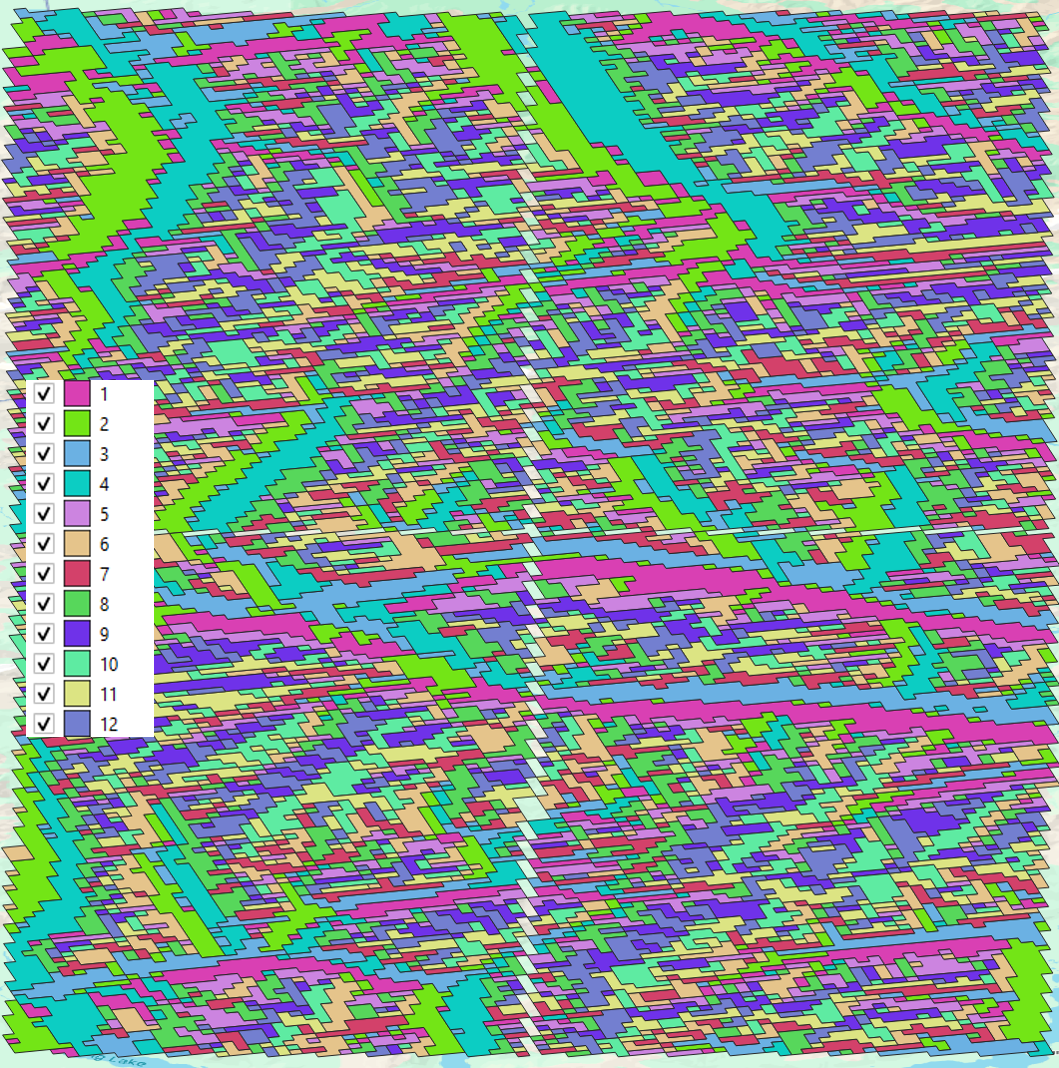

In [55]:
display(HTML(display_image_gh_notebook('5C-all-topounits-4gridcells.PNG')))

Below is an image of the properties table of the Topounit GeoDataFrame we exported to show you that each Topounit has all the properties needed to identify which elevantion bin and/or aspect range it represents.


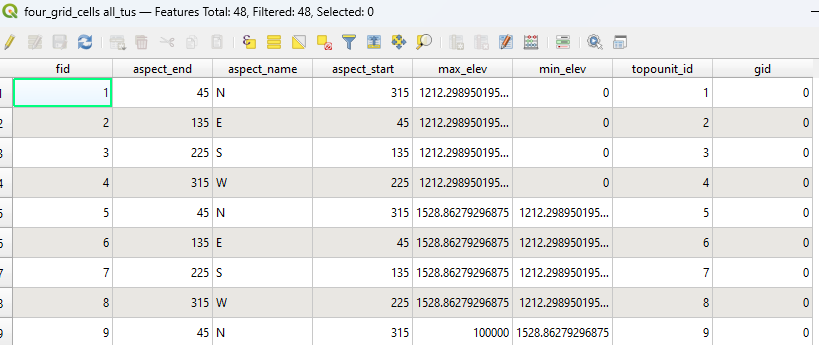

In [56]:
display(HTML(display_image_gh_notebook('5C-topounit-attribute-table.PNG')))